In [2]:
!pip install yfinance yahoofinancials pandas numpy matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.9/51.9 kB 1.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for yahoofinancials: filename=yahoofinancials-1.20-py3-none-any.whl size=38618 sha256=0730800e7a22711b52cfa587df1cfb62660cd59fea1082fb676ae2d068723556
  Stored in directory: /root/.cache/pip/wheels/b0/e1/ca/e683b02e57db550881c8ebb89ba3eccb7a5c0ebfad7f03acea
Successfully built yahoofinancials


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from yahoofinancials import YahooFinancials
import warnings
warnings.filterwarnings('ignore')

In [4]:
import requests
from bs4 import BeautifulSoup

headers = {'User-Agent': 'Mozilla/5.0'}
url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.content, 'html.parser')
table = pd.read_html(str(soup.find('table', {'id': 'constituents'})))[0]
tickers = table['Symbol'].tolist()
print(f"Total tickers extracted: {len(tickers)}")
print(tickers[:10])

Total tickers extracted: 503
['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']


In [5]:
# Download S&P 500 stock data from 2022 to 2025
start_date = '2022-01-01'
end_date = '2025-01-01'

print("Downloading stock data... please wait")
raw_data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)

# Extract closing prices only
prices = raw_data['Close']
print(f"Data shape: {prices.shape}")
print(f"Date range: {prices.index[0]} to {prices.index[-1]}")
print(prices.head())

[*********************100%***********************]  503 of 503 completed
ERROR:yfinance:
4 Failed downloads:
ERROR:yfinance:['Q', 'SNDK']: YFPricesMissingError('possibly delisted; no price data found  (1d 2022-01-01 -> 2025-01-01) (Yahoo error = "Data doesn\'t exist for startDate = 1641013200, endDate = 1735707600")')
ERROR:yfinance:['BRK.B']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:['BF.B']: YFPricesMissingError('possibly delisted; no price data found  (1d 2022-01-01 -> 2025-01-01)')


Data shape: (753, 503)
Date range: 2022-01-03 00:00:00 to 2024-12-31 00:00:00
Ticker               A        AAPL        ABBV        ABNB         ABT  \
Date                                                                     
2022-01-03  151.702118  178.103653  114.894043  172.679993  127.545784   
2022-01-04  146.573654  175.843231  114.673439  170.800003  124.546158   
2022-01-05  144.062729  171.165817  115.275841  162.250000  123.986572   
2022-01-06  144.566849  168.308517  114.732834  159.750000  123.968216   
2022-01-07  140.718063  168.474854  114.435890  166.050003  124.353500   

Ticker           ACGL         ACN        ADBE         ADI        ADM  ...  \
Date                                                                  ...   
2022-01-03  42.362530  380.485260  564.369995  164.526459  60.037270  ...   
2022-01-04  42.914051  377.766266  554.000000  163.040497  61.151543  ...   
2022-01-05  42.410072  371.113586  514.429993  160.523575  60.673992  ...   
2022-01-06  42.657

In [6]:
# Remove the 4 failed tickers and any columns with too many missing values
prices_clean = prices.dropna(axis=1, thresh=int(0.9 * len(prices)))

# Also remove any remaining rows with missing values
prices_clean = prices_clean.dropna()

print(f"Original data shape: {prices.shape}")
print(f"Cleaned data shape: {prices_clean.shape}")
print(f"Removed {prices.shape[1] - prices_clean.shape[1]} tickers due to missing data")

Original data shape: (753, 503)
Cleaned data shape: (742, 494)
Removed 9 tickers due to missing data


In [7]:
# Calculate Daily Return = (Price Today - Price Yesterday) / Price Yesterday
daily_returns = prices_clean.pct_change()

# Remove first row
daily_returns = daily_returns.dropna()

print(f"Daily returns shape: {daily_returns.shape}")
print("\nSample daily returns:")
print(daily_returns.head())
print("\nDescriptive statistics:")
print(daily_returns.describe())

Daily returns shape: (741, 494)

Sample daily returns:
Ticker             A      AAPL      ABBV      ABNB       ABT      ACGL  \
Date                                                                     
2022-01-20 -0.006765 -0.010347 -0.016123  0.022124 -0.010631 -0.006315   
2022-01-21 -0.014124 -0.012765 -0.007893 -0.008038  0.008981 -0.009643   
2022-01-24  0.004436 -0.004864  0.001364 -0.056339 -0.015974  0.011286   
2022-01-25 -0.025702 -0.011385  0.007037 -0.022583 -0.004442 -0.009847   
2022-01-26 -0.007877 -0.000563  0.008566 -0.016740 -0.025959 -0.004862   

Ticker           ACN      ADBE       ADI       ADM  ...        WY      WYNN  \
Date                                                ...                       
2022-01-20 -0.003054 -0.011092 -0.027168 -0.029719  ... -0.022716 -0.022008   
2022-01-21 -0.020602 -0.021415  0.005610  0.000726  ... -0.007313 -0.016648   
2022-01-24  0.010041  0.039507  0.012036 -0.005077  ...  0.022099 -0.009924   
2022-01-25 -0.011947 -0.032598 

In [8]:
# Download S&P 500 index data as market benchmark
sp500_index = yf.download('^GSPC', start='2022-01-01', end='2025-01-01', auto_adjust=True)
market_returns = sp500_index['Close'].pct_change().dropna()

# Flatten market returns to 1D series
market_returns = market_returns.squeeze()

# Align dates between stock returns and market returns
market_returns = market_returns.reindex(daily_returns.index).dropna()

# Align stock returns to same dates
daily_returns_aligned = daily_returns.reindex(market_returns.index)

# Calculate Beta for each stock
market_std = market_returns.std()

betas = {}
for ticker in daily_returns_aligned.columns:
    stock_returns = daily_returns_aligned[ticker].dropna()
    aligned_market = market_returns.reindex(stock_returns.index)
    correlation = stock_returns.corr(aligned_market)
    stock_std = stock_returns.std()
    beta = correlation * (stock_std / market_std)
    betas[ticker] = beta

betas_series = pd.Series(betas)
print("Beta calculation complete!")
print(f"\nSample beta values:")
print(betas_series.head(10))
print(f"\nBeta statistics:")
print(betas_series.describe())

[*********************100%***********************]  1 of 1 completed


Beta calculation complete!

Sample beta values:
A       1.020325
AAPL    1.208651
ABBV    0.300454
ABNB    1.657530
ABT     0.672620
ACGL    0.569570
ACN     1.090899
ADBE    1.443256
ADI     1.337748
ADM     0.556587
dtype: float64

Beta statistics:
count    494.000000
mean       0.945893
std        0.429771
min        0.137981
25%        0.638747
50%        0.913745
75%        1.154554
max        3.299275
dtype: float64


In [9]:
# Annual Volatility = Daily Return Standard Deviation × √252
# 252 = number of trading days in a year

annual_volatility = daily_returns_aligned.std() * np.sqrt(252)

print("Annual Volatility calculation complete!")
print(f"\nSample volatility values:")
print(annual_volatility.head(10))
print(f"\nVolatility statistics:")
print(annual_volatility.describe())

Annual Volatility calculation complete!

Sample volatility values:
Ticker
A       0.295955
AAPL    0.271223
ABBV    0.220825
ABNB    0.467084
ABT     0.218023
ACGL    0.254839
ACN     0.268642
ADBE    0.382561
ADI     0.318439
ADM     0.295763
dtype: float64

Volatility statistics:
count    494.000000
mean       0.314698
std        0.114963
min        0.156764
25%        0.241167
50%        0.284839
75%        0.357696
max        1.346522
dtype: float64


In [10]:
# Calculate mean daily return per stock
mean_daily_return = daily_returns_aligned.mean()

# Combine all metrics
metrics_df = pd.DataFrame({
    'Daily_Return': mean_daily_return,
    'Beta': betas_series,
    'Annual_Volatility': annual_volatility
}).dropna()

print(f"Final metrics dataframe shape: {metrics_df.shape}")
print("\nSample data:")
print(metrics_df.head(10))
print("\nDescriptive statistics:")
print(metrics_df.describe())

Final metrics dataframe shape: (494, 3)

Sample data:
      Daily_Return      Beta  Annual_Volatility
A         0.000141  1.020325           0.295955
AAPL      0.000721  1.208651           0.271223
ABBV      0.000606  0.300454           0.220825
ABNB      0.000216  1.657530           0.467084
ABT       0.000019  0.672620           0.218023
ACGL      0.001140  0.569570           0.254839
ACN       0.000232  1.090899           0.268642
ADBE      0.000092  1.443256           0.382561
ADI       0.000631  1.337748           0.318439
ADM      -0.000173  0.556587           0.295763

Descriptive statistics:
       Daily_Return        Beta  Annual_Volatility
count    494.000000  494.000000         494.000000
mean       0.000505    0.945893           0.314698
std        0.000683    0.429771           0.114963
min       -0.001485    0.137981           0.156764
25%        0.000087    0.638747           0.241167
50%        0.000434    0.913745           0.284839
75%        0.000814    1.154554     

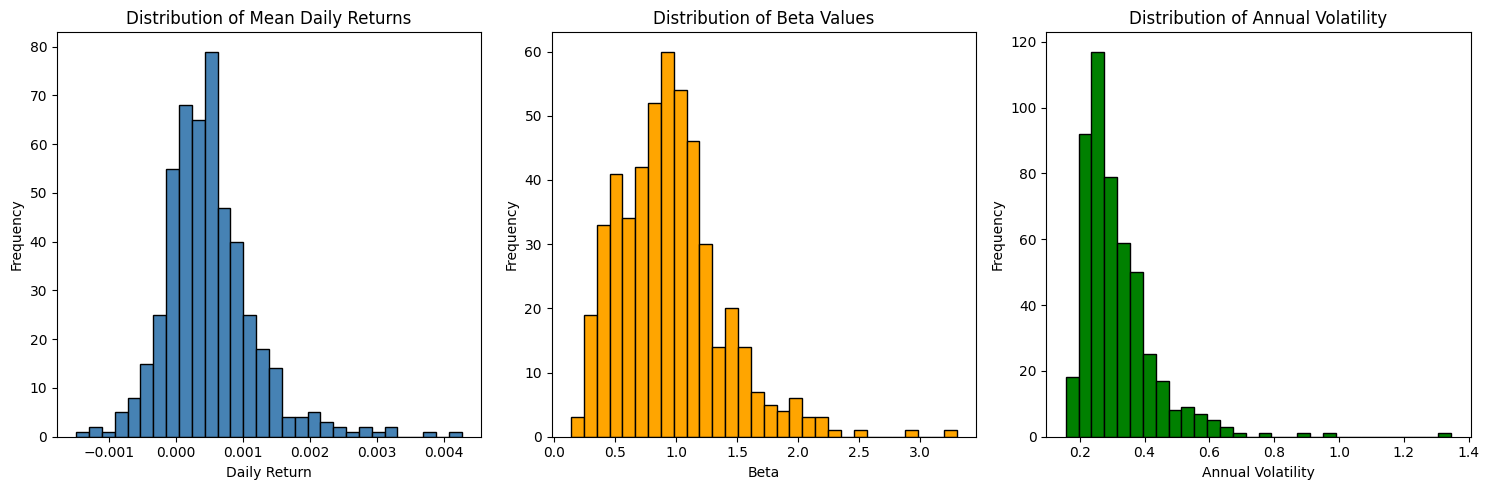

Task A visualisations complete!


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Daily Return distribution
axes[0].hist(metrics_df['Daily_Return'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Mean Daily Returns')
axes[0].set_xlabel('Daily Return')
axes[0].set_ylabel('Frequency')

# Plot 2: Beta distribution
axes[1].hist(metrics_df['Beta'], bins=30, color='orange', edgecolor='black')
axes[1].set_title('Distribution of Beta Values')
axes[1].set_xlabel('Beta')
axes[1].set_ylabel('Frequency')

# Plot 3: Annual Volatility distribution
axes[2].hist(metrics_df['Annual_Volatility'], bins=30, color='green', edgecolor='black')
axes[2].set_title('Distribution of Annual Volatility')
axes[2].set_xlabel('Annual Volatility')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('task_a_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Task A visualisations complete!")

In [12]:
from sklearn.preprocessing import StandardScaler

# Standardise the data before clustering
scaler = StandardScaler()
metrics_scaled = scaler.fit_transform(metrics_df)
metrics_scaled_df = pd.DataFrame(
    metrics_scaled,
    columns=['Daily_Return', 'Beta', 'Annual_Volatility'],
    index=metrics_df.index
)

print("Data scaling complete!")
print("\nScaled data sample:")
print(metrics_scaled_df.head())
print("\nScaled data statistics:")
print(metrics_scaled_df.describe())

Data scaling complete!

Scaled data sample:
      Daily_Return      Beta  Annual_Volatility
A        -0.532487  0.173366          -0.163205
AAPL      0.316779  0.612010          -0.378550
ABBV      0.149517 -1.503343          -0.817382
ABNB     -0.422949  1.657529           1.326858
ABT      -0.712051 -0.636502          -0.841776

Scaled data statistics:
       Daily_Return          Beta  Annual_Volatility
count  4.940000e+02  4.940000e+02       4.940000e+02
mean   1.797932e-18  1.941767e-16       7.910901e-17
std    1.001014e+00  1.001014e+00       1.001014e+00
min   -2.917356e+00 -1.881771e+00      -1.375173e+00
25%   -6.126132e-01 -7.153977e-01      -6.402557e-01
50%   -1.040912e-01 -7.487807e-02      -2.599940e-01
75%    4.535532e-01  4.860086e-01       3.743952e-01
max    5.516601e+00  5.481444e+00       8.984338e+00


Calculating linkage matrix... please wait


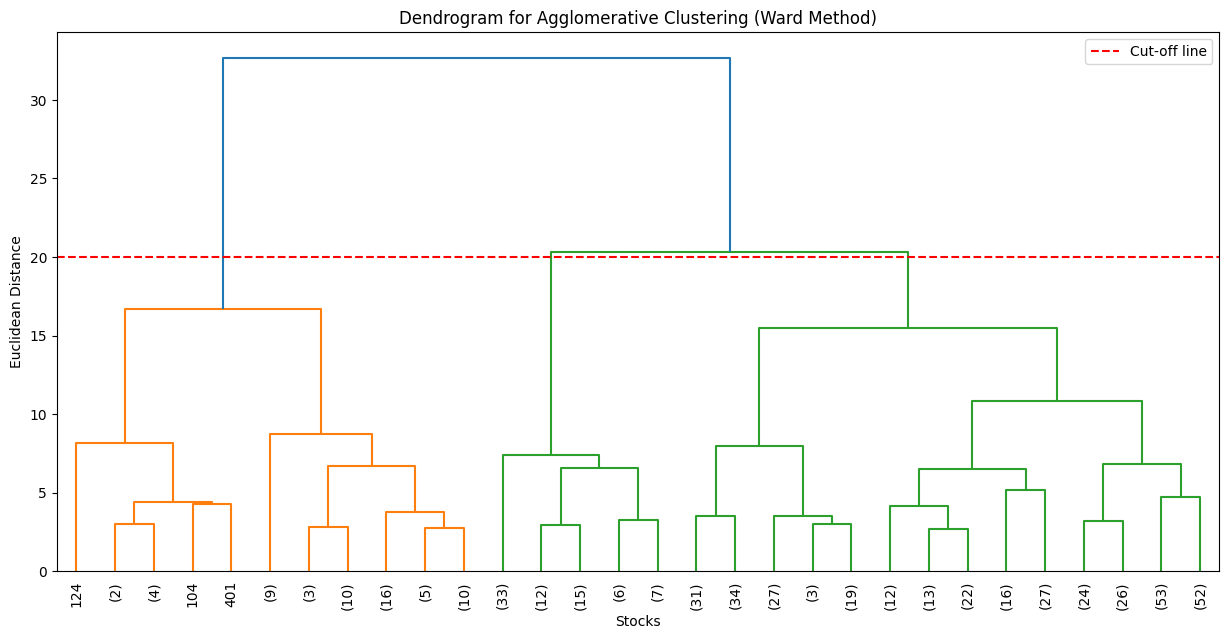

Dendrogram complete!


In [13]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Calculate linkage matrix
print("Calculating linkage matrix... please wait")
linked = linkage(metrics_scaled_df, method='ward')

# Plot dendrogram
plt.figure(figsize=(15, 7))
dendrogram(linked,
           truncate_mode='lastp',
           p=30,
           show_leaf_counts=True,
           leaf_rotation=90,
           leaf_font_size=10)
plt.title('Dendrogram for Agglomerative Clustering (Ward Method)')
plt.xlabel('Stocks')
plt.ylabel('Euclidean Distance')
plt.axhline(y=20, color='red', linestyle='--', label='Cut-off line')
plt.legend()
plt.savefig('dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dendrogram complete!")

In [16]:
from sklearn.cluster import AgglomerativeClustering

# Apply Agglomerative Clustering with 3 clusters
agg_cluster = AgglomerativeClustering(n_clusters=3, linkage='ward')
metrics_df['Agglomerative_Cluster'] = agg_cluster.fit_predict(metrics_scaled_df)

# Show cluster summary
print("Agglomerative Clustering complete!")
print(f"\nCluster distribution:")
print(metrics_df['Agglomerative_Cluster'].value_counts())

print("\nCluster profiles:")
print(metrics_df.groupby('Agglomerative_Cluster')[
    ['Daily_Return', 'Beta', 'Annual_Volatility']
].mean())

Agglomerative Clustering complete!

Cluster distribution:
Agglomerative_Cluster
1    359
2     73
0     62
Name: count, dtype: int64

Cluster profiles:
                       Daily_Return      Beta  Annual_Volatility
Agglomerative_Cluster                                           
0                          0.001566  1.628068           0.499384
1                          0.000452  0.764906           0.265745
2                         -0.000138  1.256571           0.398587


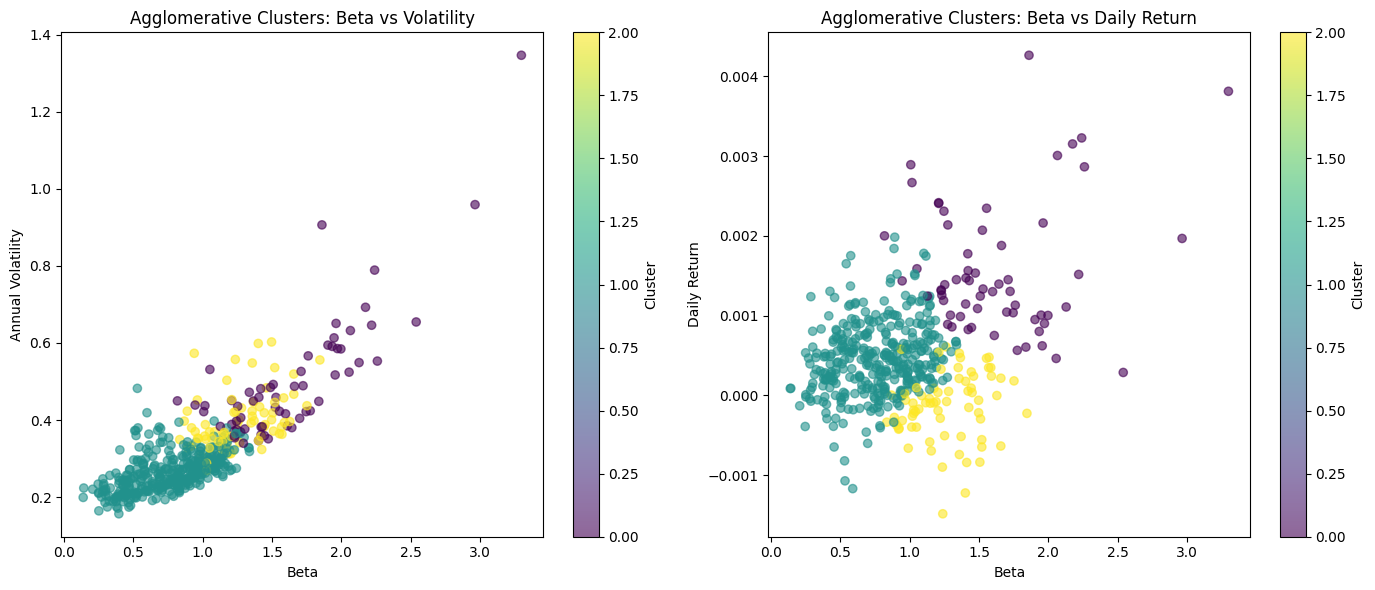

Agglomerative clustering visualisation complete!


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Beta vs Annual Volatility
scatter1 = axes[0].scatter(
    metrics_df['Beta'],
    metrics_df['Annual_Volatility'],
    c=metrics_df['Agglomerative_Cluster'],
    cmap='viridis', alpha=0.6)
axes[0].set_title('Agglomerative Clusters: Beta vs Volatility')
axes[0].set_xlabel('Beta')
axes[0].set_ylabel('Annual Volatility')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Plot 2: Beta vs Daily Return
scatter2 = axes[1].scatter(
    metrics_df['Beta'],
    metrics_df['Daily_Return'],
    c=metrics_df['Agglomerative_Cluster'],
    cmap='viridis', alpha=0.6)
axes[1].set_title('Agglomerative Clusters: Beta vs Daily Return')
axes[1].set_xlabel('Beta')
axes[1].set_ylabel('Daily Return')
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.savefig('agglomerative_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print("Agglomerative clustering visualisation complete!")

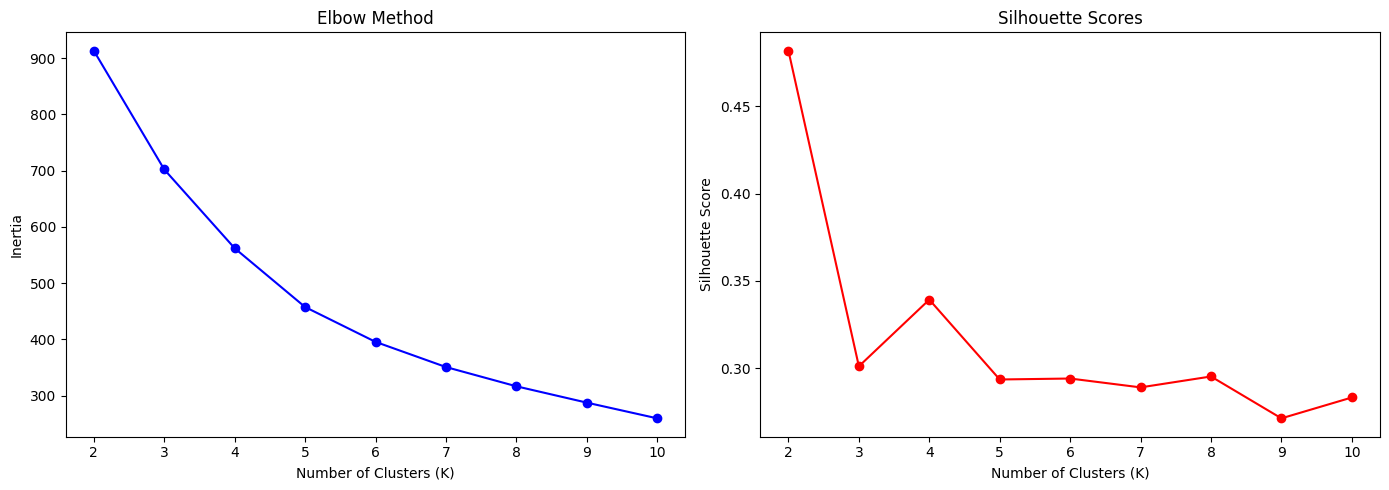

Optimal K analysis complete!

Silhouette scores:
K=2: 0.4818
K=3: 0.3011
K=4: 0.3393
K=5: 0.2935
K=6: 0.2941
K=7: 0.2890
K=8: 0.2952
K=9: 0.2713
K=10: 0.2832


In [18]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Test K from 2 to 10
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(metrics_scaled_df)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(metrics_scaled_df, kmeans.labels_))

# Plot Elbow curve and Silhouette scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(k_range, inertias, 'bo-')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')

# Silhouette scores
axes[1].plot(k_range, silhouette_scores, 'ro-')
axes[1].set_title('Silhouette Scores')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.savefig('kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

print("Optimal K analysis complete!")
print("\nSilhouette scores:")
for k, score in zip(k_range, silhouette_scores):
    print(f"K={k}: {score:.4f}")

In [19]:
from sklearn.cluster import KMeans

# Apply K-Means with K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
metrics_df['KMeans_Cluster'] = kmeans.fit_predict(metrics_scaled_df)

# Show cluster summary
print("K-Means Clustering complete!")
print(f"\nCluster distribution:")
print(metrics_df['KMeans_Cluster'].value_counts())

print("\nCluster profiles:")
print(metrics_df.groupby('KMeans_Cluster')[
    ['Daily_Return', 'Beta', 'Annual_Volatility']
].mean())

K-Means Clustering complete!

Cluster distribution:
KMeans_Cluster
2    234
0    213
1     47
Name: count, dtype: int64

Cluster profiles:
                Daily_Return      Beta  Annual_Volatility
KMeans_Cluster                                           
0                   0.000383  1.132549           0.344580
1                   0.001733  1.724323           0.536739
2                   0.000368  0.619637           0.242901


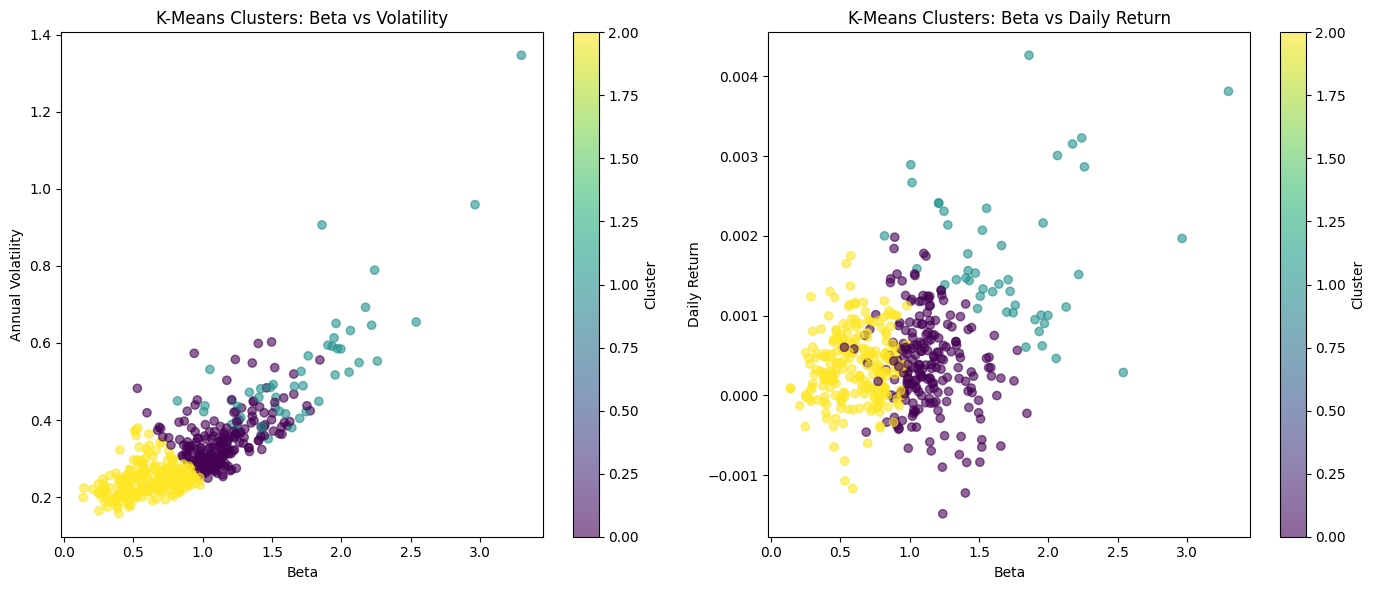

K-Means visualisation complete!


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Beta vs Annual Volatility
scatter1 = axes[0].scatter(
    metrics_df['Beta'],
    metrics_df['Annual_Volatility'],
    c=metrics_df['KMeans_Cluster'],
    cmap='viridis', alpha=0.6)
axes[0].set_title('K-Means Clusters: Beta vs Volatility')
axes[0].set_xlabel('Beta')
axes[0].set_ylabel('Annual Volatility')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Plot 2: Beta vs Daily Return
scatter2 = axes[1].scatter(
    metrics_df['Beta'],
    metrics_df['Daily_Return'],
    c=metrics_df['KMeans_Cluster'],
    cmap='viridis', alpha=0.6)
axes[1].set_title('K-Means Clusters: Beta vs Daily Return')
axes[1].set_xlabel('Beta')
axes[1].set_ylabel('Daily Return')
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print("K-Means visualisation complete!")